# IDX Exchange Exploratory Data Analysis

Exploratory analysis of CRMLS listings and sold datasets for the IDX Exchange project.

This notebook compares the two core datasets, reviews schema and missingness, and profiles key numeric fields for distribution and outlier behavior.

By Jack Phelan

## Table of Contents

- [Setup and Data Loading](#Setup-and-Data-Loading)
- [Listings Analysis](#Listings-Analysis)
  - [Listings Dataset Overview](#Listings-Dataset-Overview)
    - [Data Type Notes](#Data-Type-Notes)
  - [Listings Missingness Assessment](#Listings-Missingness-Assessment)
  - [Listings Distribution Analysis](#Listings-Distribution-Analysis)
    - [Fields Reviewed](#Fields-Reviewed)
  - [Listings Outlier Detection](#Listings-Outlier-Detection)
    - [Outlier Notes](#Outlier-Notes)
- [Sold Analysis](#Sold-Analysis)
  - [Sold Dataset Overview](#Sold-Dataset-Overview)
  - [Sold Missingness Assessment](#Sold-Missingness-Assessment)
  - [Sold Distribution Analysis](#Sold-Distribution-Analysis)
  - [Sold Outlier Detection](#Sold-Outlier-Detection)

## Setup and Data Loading

This section imports the analysis helpers, loads the concatenated CSV extracts, and previews the raw listings and sold datasets used throughout the notebook.

In [54]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from idx.utils import get_histogram, get_boxplot, get_missing_report, get_iqr_outliers
from idx.config import RAW_LISTINGS_DIR, RAW_SOLD_DIR
import numpy as np
import scipy.stats as stats
from pathlib import Path
from data_profiling import ProfileReport
from IPython.display import display

In [55]:
# loading data from concat-ed csv
listings_df_raw = pd.read_csv(Path("..") / RAW_LISTINGS_DIR, low_memory=False)
sold_df_raw = pd.read_csv(Path("..") / RAW_SOLD_DIR, low_memory=False)

In [56]:
# previews
listings_df_raw.head(5)

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1,BuyerAgencyCompensationType,BuyerAgencyCompensation
0,929000.0,1076194146,dianne@drector.com,NaN,NaN,Dianne,Rector,NaN,NaN,16882 Canyon Lane,...,2.0,Huntington Beach Union High,92649,NaN,330.0,1847.0,NaN,16882 Canyon Lane,NaN,NaN
1,999999.0,1076194026,realestateby_denisegarcia@gmail.com,NaN,NaN,Denise,Garcia,NaN,NaN,8720 S 4th Avenue,...,2.0,Inglewood Unified,90305,NaN,0.0,8508.0,NaN,8720 S 4th Avenue,NaN,NaN
2,1400000.0,1076193814,alizabethjames@hotmail.com,NaN,NaN,Alizabeth,James,33.858559,-116.542169,505 E Molino Road,...,2.0,Palm Springs Unified,92262,NaN,NaN,10890.0,NaN,505 E Molino Road,NaN,NaN
3,4998888.0,1076193812,ernieramos62@yahoo.com,NaN,NaN,Ernesto,Ramos,NaN,NaN,3653 Halldale Avenue,...,0.0,NaN,90018,NaN,NaN,6192.0,NaN,3653 Halldale Avenue,NaN,NaN
4,549000.0,1076193525,parsanina@yahoo.com,NaN,NaN,Nina,Parsa,NaN,NaN,1736 N Mcdivitt Avenue,...,2.0,Los Angeles Unified,90221,NaN,0.0,4113.0,NaN,1736 N Mcdivitt Avenue,NaN,NaN


In [57]:
sold_df_raw.head(5)

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
0,NaN,True,NaN,NaN,NaN,159000.0,555125771,deborah.potestio@c21selectgroup.com,2024-04-29,45000.0,...,95916,0.0,336283.2,NaN,False,False,NaN,NaN,NaN,NaN
1,NaN,True,NaN,NaN,NaN,144000.0,554271746,crchapman@sbcglobal.net,2024-04-26,78000.0,...,95966,0.0,101495.0,NaN,False,False,NaN,NaN,NaN,NaN
2,NaN,True,NaN,NaN,False,265000.0,543251400,michaelg@londonproperties.com,2024-04-02,250000.0,...,93726,0.0,8100.0,NaN,False,False,NaN,NaN,NaN,NaN
3,NaN,True,NaN,NaN,NaN,925000.0,539236677,chris.campbell@msn.com,2024-04-10,815000.0,...,92223,0.0,564988.0,NaN,False,False,NaN,NaN,NaN,NaN
4,NaN,True,NaN,NaN,NaN,25000.0,538449222,rrinder@sbcglobal.net,2024-04-06,15000.0,...,95966,0.0,6098.0,NaN,False,False,NaN,NaN,NaN,NaN


## Listings Analysis

The listings section establishes the dataset shape and types, then moves through missingness, numeric distributions, and outlier checks.

### Listings Dataset Overview

Start with the basic schema, shape, and column-type profile for the listings extract.

In [58]:
# basic info about data
print("Listings DataFrame Info:")
print(listings_df_raw.shape[0], "rows,", listings_df_raw.shape[1], "columns")
print("Number of float columns:", len(listings_df_raw.select_dtypes(include=['float64']).columns.tolist()))
print("Number of int columns:", len(listings_df_raw.select_dtypes(include=['int64']).columns.tolist()))
print("Number of object columns:", len(listings_df_raw.select_dtypes(include=['object']).columns.tolist()))
print("Number of string columns:", len(listings_df_raw.select_dtypes(include=['string']).columns.tolist()))

Listings DataFrame Info:
893594 rows, 84 columns
Number of float columns: 32
Number of int columns: 4
Number of object columns: 48
Number of string columns: 0


In [59]:
# specific dtypes 
display(listings_df_raw.dtypes) #low_memory=False on read changes str columns to objects

OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
                                 ...   
LotSizeSquareFeet               float64
MiddleOrJuniorSchoolDistrict    float64
UnparsedAddress.1                object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 84, dtype: object

In [60]:
listings_df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893594 entries, 0 to 893593
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             890150 non-null  float64
 1   ListingKey                    893594 non-null  int64  
 2   ListAgentEmail                891222 non-null  object 
 3   CloseDate                     257985 non-null  object 
 4   ClosePrice                    233372 non-null  float64
 5   ListAgentFirstName            888314 non-null  object 
 6   ListAgentLastName             893511 non-null  object 
 7   Latitude                      781122 non-null  float64
 8   Longitude                     781848 non-null  float64
 9   UnparsedAddress               891239 non-null  object 
 10  PropertyType                  893594 non-null  object 
 11  LivingArea                    782759 non-null  float64
 12  ListPrice                     891376 non-nul

#### Data Type Notes

- Date columns are stored as strings rather than datetimes.
- Most date fields are sparsely populated, so this may not materially affect the current EDA.
- Confirm expected date handling with the data source owner before downstream cleaning work.

### Listings Missingness Assessment

In [61]:
listings_missing_report = get_missing_report(listings_df_raw, flag_high_missing=True, threshold=0.9, index_col='column')

display(listings_missing_report)

,missing_count,pct_missing,high_missing
column,,,
FireplacesTotal,893594,100.0,True
ElementarySchoolDistrict,893594,100.0,True
MiddleOrJuniorSchoolDistrict,893594,100.0,True
CoveredSpaces,893594,100.0,True
AboveGradeFinishedArea,893594,100.0,True
...,...,...,...
MlsStatus,0,0.0,False
ListingKey,0,0.0,False
ListingId,0,0.0,False


In [62]:
# COLUMN GROUP DECLARATIONS
METADATA_COLS = [
    "ListingKey",
    "BuyerAgentMlsId",
    "ListingKeyNumeric",
    "MlsStatus",
    "ListingId",
]


# COLUMNS THAT SHOULD PROBABLY BE DROPPED
COLS_TO_DROP = listings_missing_report[
    listings_missing_report["high_missing"]
].index.tolist()  # 90% Missing or more

AGENT_COLS = [
    "ListAgentEmail",
    "ListAgentFirstName",
    "ListAgentLastName",
    "ListOfficeName",
    "BuyerOfficeName",
    "CoListOfficeName",
    "ListAgentFullName",
    "CoListAgentFirstName",
    "CoListAgentLastName",
    "BuyerAgentMlsId",
    "BuyerAgentFirstName",
    "BuyerAgentLastName",
    "ListAgentFirstName.1",
    "BuyerOfficeAOR",
    "CoBuyerAgentFirstName",
    "ListAgentLastName.1",
    "BuyerOfficeName.1",
    "BuyerAgencyCompensationType",
    "BuyerAgencyCompensation",
]

REGIONAL_COLS = [
    "Latitude",
    "Longitude",
    "UnparsedAddress",
    "AboveGradeFinishedArea",
    "MLSAreaMajor",
    "CountyOrParish",
    "ElementarySchool",
    "SubdivisionName",
    "StreetNumberNumeric",
    "City",
    "Longitude.1",
    "ElementarySchoolDistrict",
    "BelowGradeFinishedArea",
    "Latitude.1",
    "StateOrProvince",
    "MiddleOrJuniorSchool",
    "HighSchool",
    "HighSchoolDistrict",
    "PostalCode",
    "MiddleOrJuniorSchoolDistrict",
    "UnparsedAddress.1",
]


# FOR LATER USAGE
NUMERIC_FIELDS_TO_ANALYZE = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "DaysOnMarket",
    "YearBuilt",
]

CONTINUOUS_COLS = [
    "ClosePrice",
    "ListPrice",
    "OriginalListPrice",
    "LivingArea",
    "LotSizeAcres",
]

DISCRETE_COLS = ["BedroomsTotal", "BathroomsTotalInteger", "YearBuilt", "DaysOnMarket"]

# CHECK DISTRIBUTION OF THESE GUYS
DISTR_COLS = ["ClosePrice", "LivingArea", "DaysOnMarket"]

### Listings Distribution Analysis

Review the main continuous and discrete numeric fields before moving into explicit outlier detection.

#### Fields Reviewed

- ClosePrice
- ListPrice
- OriginalListPrice
- LivingArea
- LotSizeAcres
- BedroomsTotal
- BathroomsTotalInteger
- DaysOnMarket
- YearBuilt

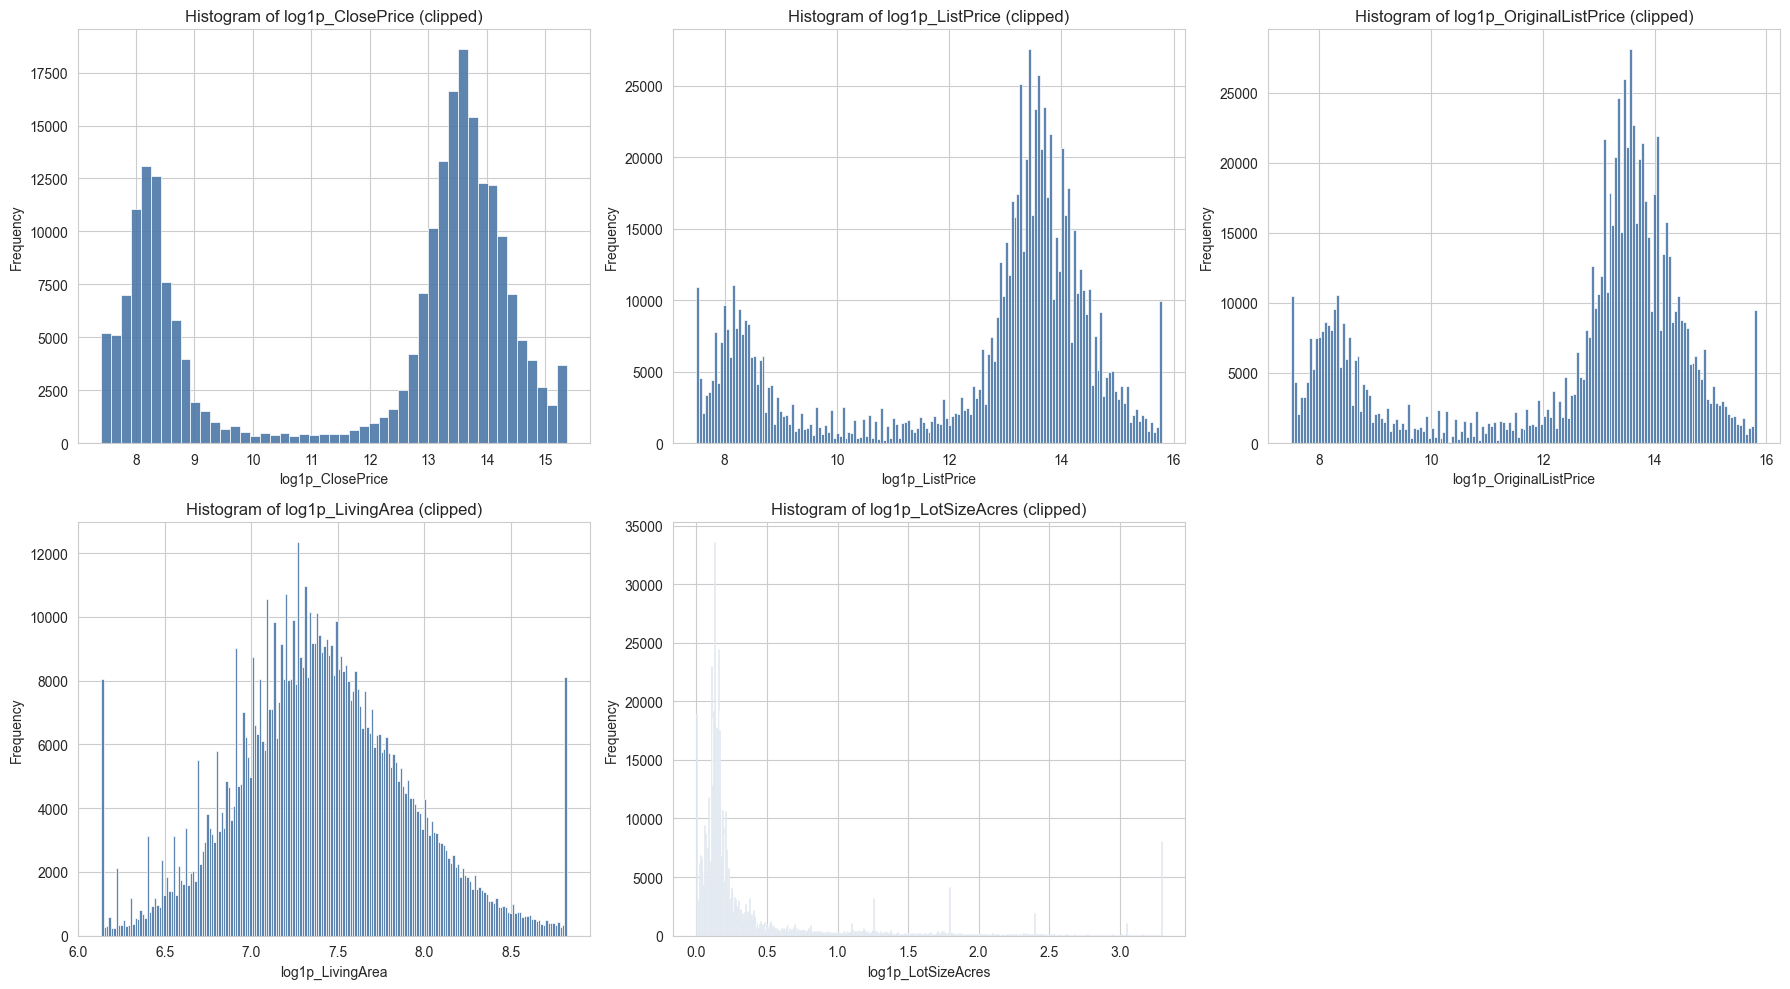

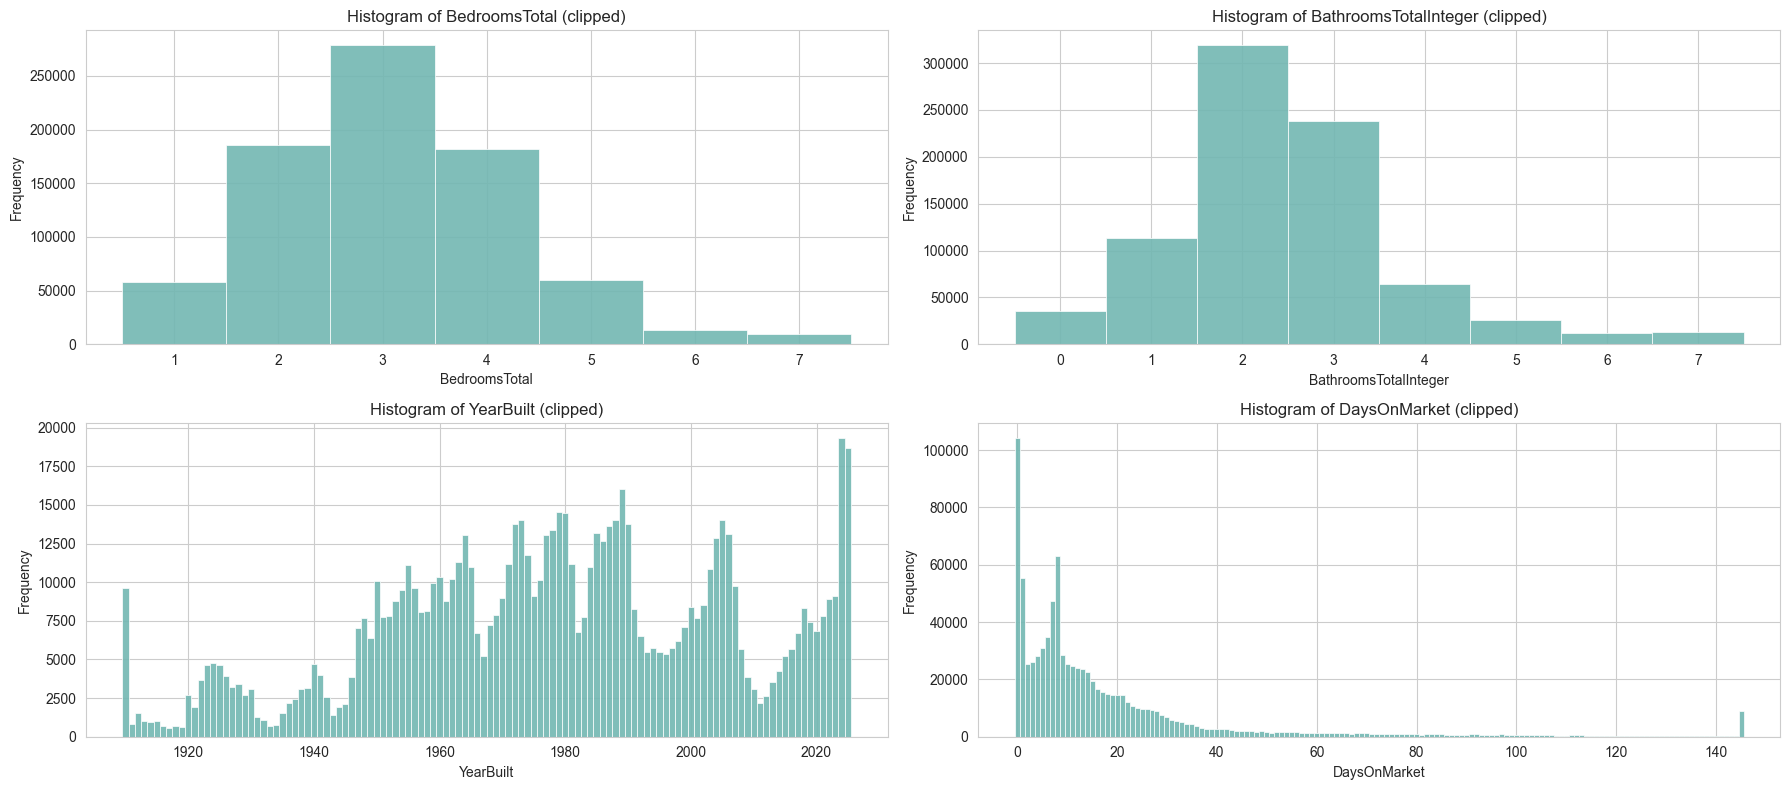

In [63]:
plot_df = listings_df_raw.copy()
plot_df["DaysOnMarket"] = pd.to_numeric(plot_df["DaysOnMarket"], errors="coerce").clip(lower=0)

# Use log1p on heavy-tailed continuous features for better shape visibility.
log_cols = []
for column in CONTINUOUS_COLS:
    log_col = f"log1p_{column}"
    values = pd.to_numeric(plot_df[column], errors="coerce").clip(lower=0)
    plot_df[log_col] = np.log1p(values)
    log_cols.append(log_col)

get_histogram(
    plot_df,
    col=log_cols,
    bins='auto',
    clip_lower=plot_df[log_cols].quantile(0.01),
    clip_upper=plot_df[log_cols].quantile(0.99),
    ncols=3,
    figsize=(18, 10),
    edgecolor="white",
    linewidth=0.5,
    color="#4C78A8",
    alpha=0.9,
    
)

get_histogram(
    plot_df,
    col=DISCRETE_COLS,
    bins='auto',
    clip_lower=plot_df[DISCRETE_COLS].quantile(0.01),
    clip_upper=plot_df[DISCRETE_COLS].quantile(0.99), #clipping needed because the scale goes insane otherwise aka lots of outliers > : (
    ncols=2,
    figsize=(18, 8),
    edgecolor="white",
    linewidth=0.5,
    color="#72B7B2",
    alpha=0.9,
    discrete=True
)


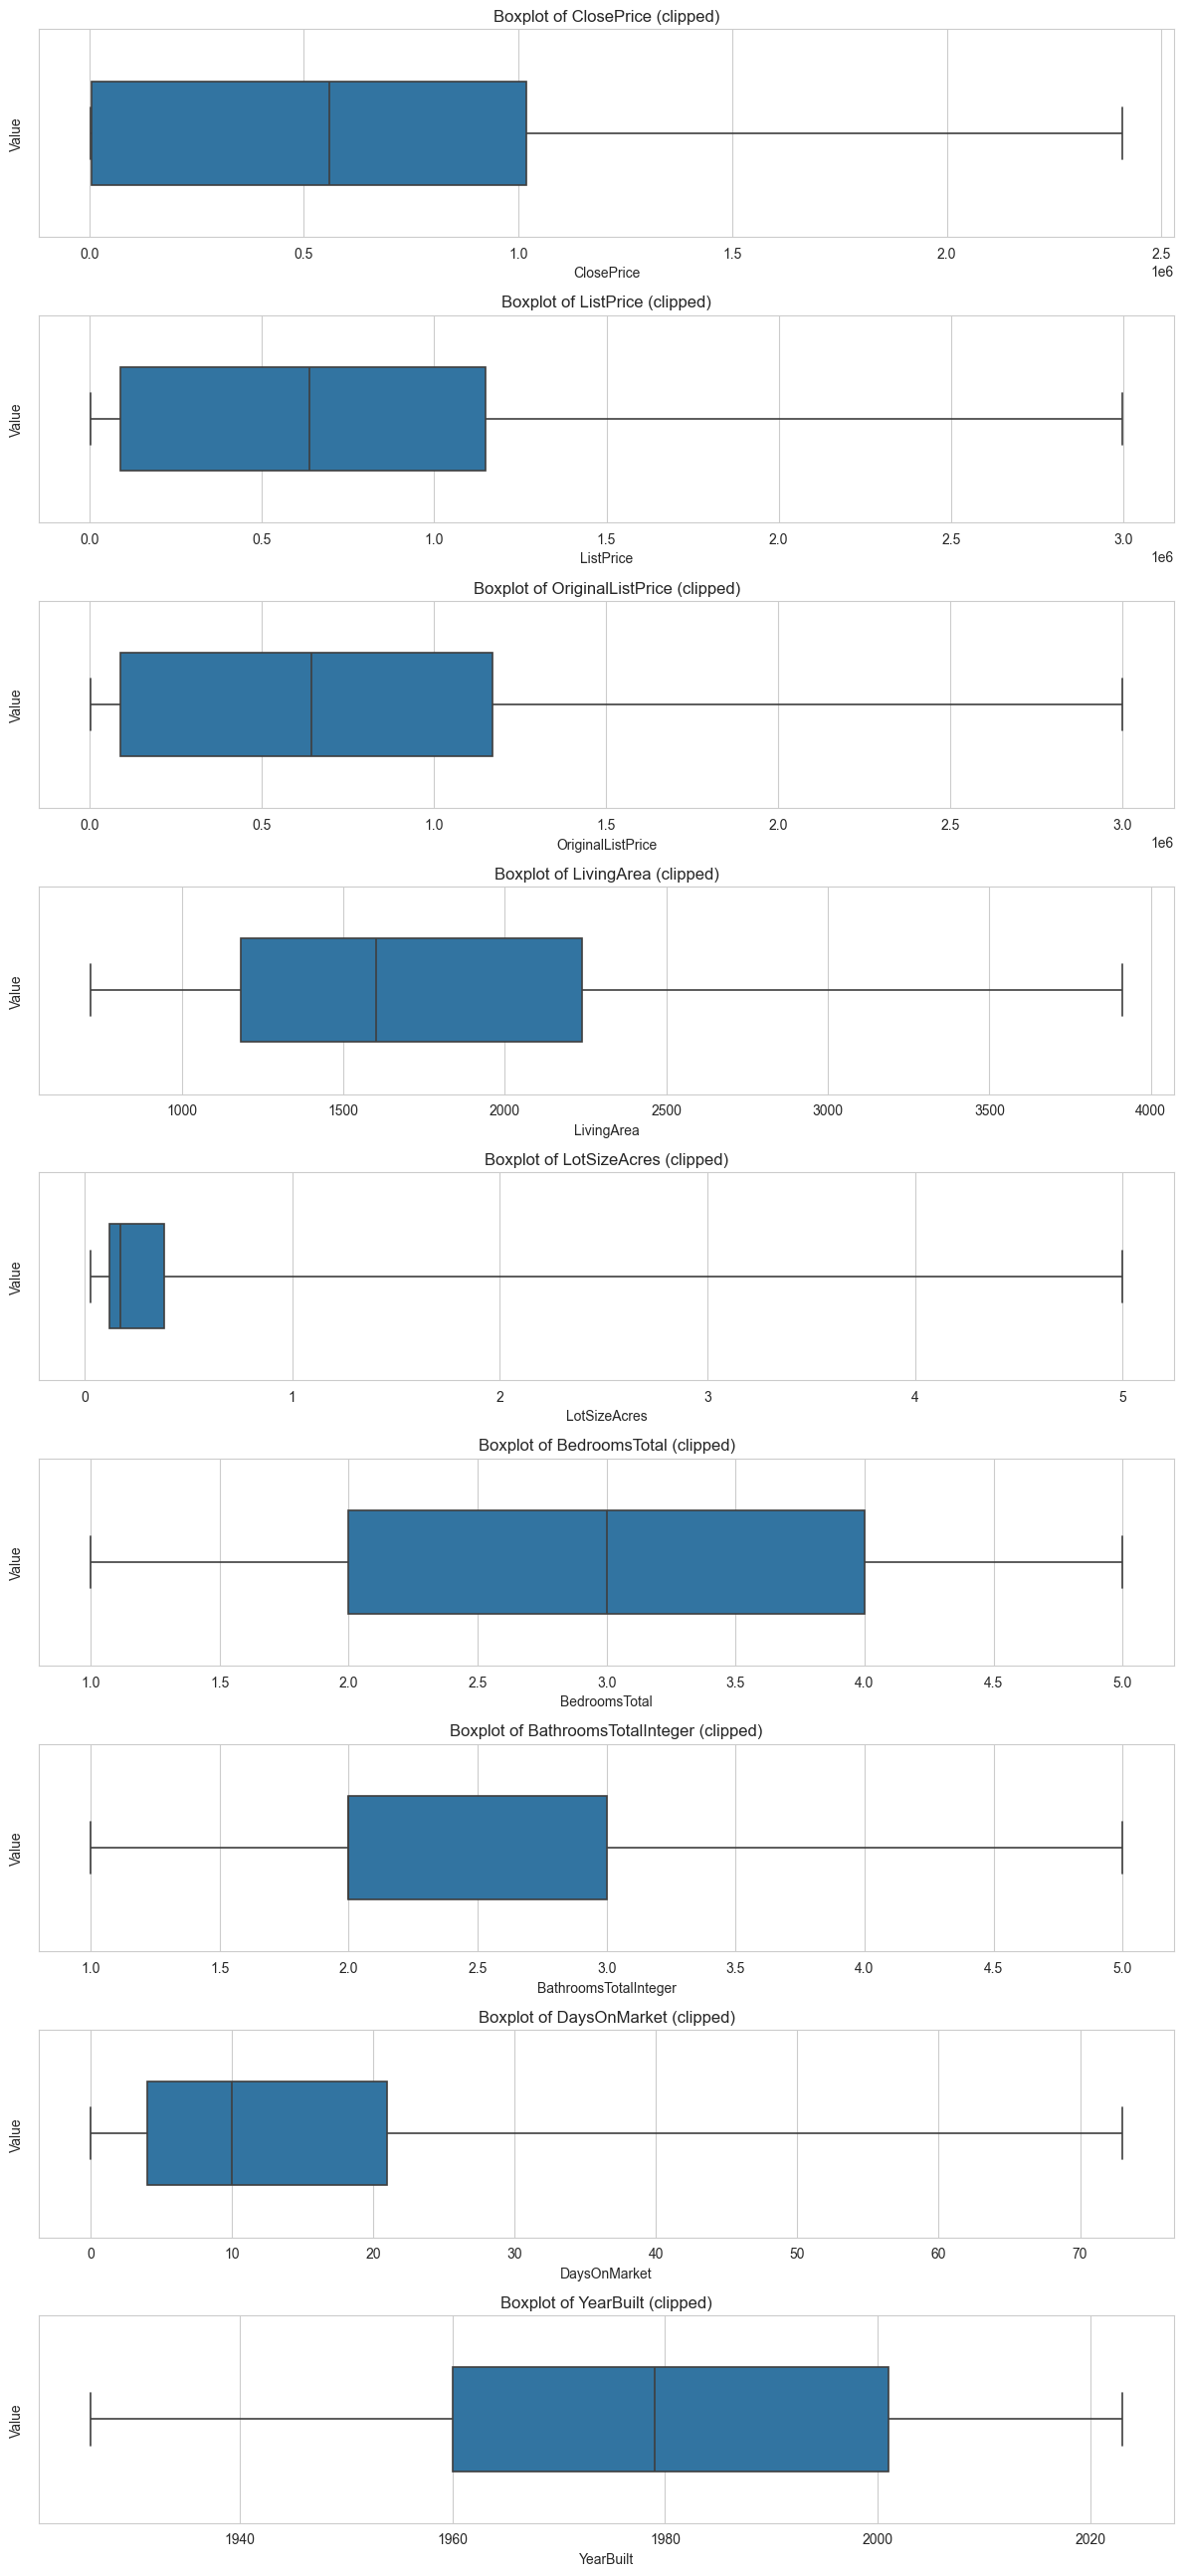

In [64]:
get_boxplot(
    listings_df_raw,
    col=NUMERIC_FIELDS_TO_ANALYZE,
    clip_lower=listings_df_raw[NUMERIC_FIELDS_TO_ANALYZE].quantile(0.01),
    clip_upper=listings_df_raw[NUMERIC_FIELDS_TO_ANALYZE].quantile(0.99),
    ncols=1,
    figsize=(12, 26),
    showfliers=False,
    whis=(5, 95),
    linewidth=1.2,
    width=0.5,
)

In [65]:
# percentile breakdowns
display(listings_df_raw[NUMERIC_FIELDS_TO_ANALYZE].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T)

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ClosePrice,233372.0,7.789454e+05,3.457924e+06,0.0,1650.0,2400.0000,3000.00,4995.0000,560000.0000,1.020000e+06,1730000.00,2410000.0,4700000.00,8.200000e+08
ListPrice,891376.0,9.887441e+05,2.210545e+06,0.0,1800.0,2800.0000,3700.00,89900.0000,639000.0000,1.150000e+06,1999000.00,2998000.0,7199999.25,4.436503e+08
OriginalListPrice,890150.0,1.056722e+06,6.456580e+06,0.0,1800.0,2850.0000,3795.00,89950.0000,644300.0000,1.169000e+06,1999999.00,3000000.0,7495000.00,1.390000e+09
LivingArea,782759.0,3.104491e+03,1.027712e+06,0.0,460.0,718.0000,880.00,1183.0000,1603.0000,2.239000e+03,3131.00,3912.0,6782.00,9.090909e+08
LotSizeAcres,808569.0,5.266537e+02,4.119048e+05,0.0,0.0,0.0288,0.06,0.1206,0.1722,3.842000e-01,2.11,5.0,26.00,3.702600e+08
BedroomsTotal,786298.0,3.135297e+00,1.697613e+00,0.0,1.0,1.0000,2.00,2.0000,3.0000,4.000000e+00,5.00,5.0,7.00,1.490000e+02
BathroomsTotalInteger,820694.0,2.502053e+00,2.994040e+00,0.0,0.0,1.0000,1.00,2.0000,2.0000,3.000000e+00,4.00,5.0,7.00,2.208000e+03
DaysOnMarket,893594.0,1.857182e+01,2.835777e+01,-58.0,0.0,0.0000,0.00,4.0000,10.0000,2.100000e+01,42.00,73.0,145.00,2.539000e+03
YearBuilt,821420.0,1.978436e+03,2.805754e+01,1776.0,1910.0,1926.0000,1942.00,1960.0000,1979.0000,2.001000e+03,2018.00,2023.0,2025.00,2.028000e+03


In [ ]:
# distribution analysis
display(listings_df_raw[DISTR_COLS].describe())


,ClosePrice,LivingArea,DaysOnMarket
count,2.333720e+05,7.827590e+05,893594.000000
mean,7.789454e+05,3.104491e+03,18.571821
std,3.457924e+06,1.027712e+06,28.357769
min,0.000000e+00,0.000000e+00,-58.000000
25%,4.995000e+03,1.183000e+03,4.000000
50%,5.600000e+05,1.603000e+03,10.000000
75%,1.020000e+06,2.239000e+03,21.000000
max,8.200000e+08,9.090909e+08,2539.000000


### Listings Outlier Detection

In [67]:
numeric_outliers = get_iqr_outliers(listings_df_raw, NUMERIC_FIELDS_TO_ANALYZE, threshold=3.0) # 3.0 for EXTREME outliers

Outlier Counts (Threshold: 3.0 * IQR)
----------------------------------------
ClosePrice: 3451 outliers (0.39% of total records)
ListPrice: 22703 outliers (2.54% of total records)
OriginalListPrice: 22752 outliers (2.55% of total records)
LivingArea: 14651 outliers (1.64% of total records)
LotSizeAcres: 108046 outliers (12.09% of total records)
BedroomsTotal: 2491 outliers (0.28% of total records)
BathroomsTotalInteger: 12589 outliers (1.41% of total records)
DaysOnMarket: 45113 outliers (5.05% of total records)
YearBuilt: 39 outliers (0.00% of total records)


#### Outlier Notes

- `DaysOnMarket` contains 10,426 zero values and 36 negative values.
- Validate whether these values reflect missing data, placeholder values, or true edge cases before modeling or reporting.

In [68]:
"""
profile = ProfileReport(listings_df_raw, title="Profiling Report", explorative=True)
profile.to_file("listings_profile_report.html")
"""

'\nprofile = ProfileReport(listings_df_raw, title="Profiling Report", explorative=True)\nprofile.to_file("listings_profile_report.html")\n'

## Sold Analysis

The sold section mirrors the listings review so the two datasets can be compared on structure, completeness, and numeric behavior.

### Sold Dataset Overview

Start with the sold dataset shape, schema profile, and a quick comparison against the listings columns.

In [ ]:
"""sold_profile = ProfileReport(sold_df_raw, title="Sold Data Profiling Report", explorative=True)
sold_profile.to_file("sold_profile_report.html")"""

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 84/84 [00:21<00:00,  3.96it/s]
/Users/jack/Repos/idx-exchange-jp/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [71]:
#basic sold info
print("Sold DataFrame Info:")
print(sold_df_raw.shape[0], "rows,", sold_df_raw.shape[1], "columns")
print("Number of float columns:", len(sold_df_raw.select_dtypes(include=['float64']).columns.tolist()))
print("Number of int columns:", len(sold_df_raw.select_dtypes(include=['int64']).columns.tolist()))
print("Number of object columns:", len(sold_df_raw.select_dtypes(include=['object']).columns.tolist()))
print("Number of string columns:", len(sold_df_raw.select_dtypes(include=['string']).columns.tolist()))
print("Number of Boolean columns:", len(sold_df_raw.select_dtypes(include=['bool']).columns.tolist()))

Sold DataFrame Info:
681599 rows, 84 columns
Number of float columns: 28
Number of int columns: 3
Number of object columns: 53
Number of string columns: 0
Number of Boolean columns: 0


In [77]:
# column overlap check
print("Columns in listings_df_raw but not in sold_df_raw:")
display(set(listings_df_raw.columns).difference(set(sold_df_raw.columns)))
print("Columns in sold_df_raw but not in listings_df_raw:")
display(set(sold_df_raw.columns).difference(set(listings_df_raw.columns)))


Columns in listings_df_raw but not in sold_df_raw:


{'BuyerOfficeName.1',
 'CloseDate.1',
 'DaysOnMarket.1',
 'Latitude.1',
 'ListAgentFirstName.1',
 'ListAgentLastName.1',
 'ListPrice.1',
 'LivingArea.1',
 'Longitude.1',
 'PropertyType.1',
 'UnparsedAddress.1'}

Columns in sold_df_raw but not in listings_df_raw:


{'BasementYN',
 'BuyerAgentAOR',
 'Flooring',
 'ListAgentAOR',
 'OriginatingSystemName',
 'OriginatingSystemSubName',
 'PoolPrivateYN',
 'ViewYN',
 'WaterfrontYN',
 'latfilled',
 'lonfilled'}

### Sold Missingness Assessment

In [78]:
sold_missing_report = get_missing_report(sold_df_raw, flag_high_missing=True, threshold=0.9, index_col='column')

display(sold_missing_report)

,missing_count,pct_missing,high_missing
column,,,
AboveGradeFinishedArea,681599,100.0,True
MiddleOrJuniorSchoolDistrict,681599,100.0,True
CoveredSpaces,681599,100.0,True
FireplacesTotal,681599,100.0,True
ElementarySchoolDistrict,681599,100.0,True
...,...,...,...
ListOfficeName,0,0.0,False
ListingKey,0,0.0,False
MlsStatus,0,0.0,False


### Sold Distribution Analysis

Review the same core numeric fields used in the listings section to keep the comparison consistent.

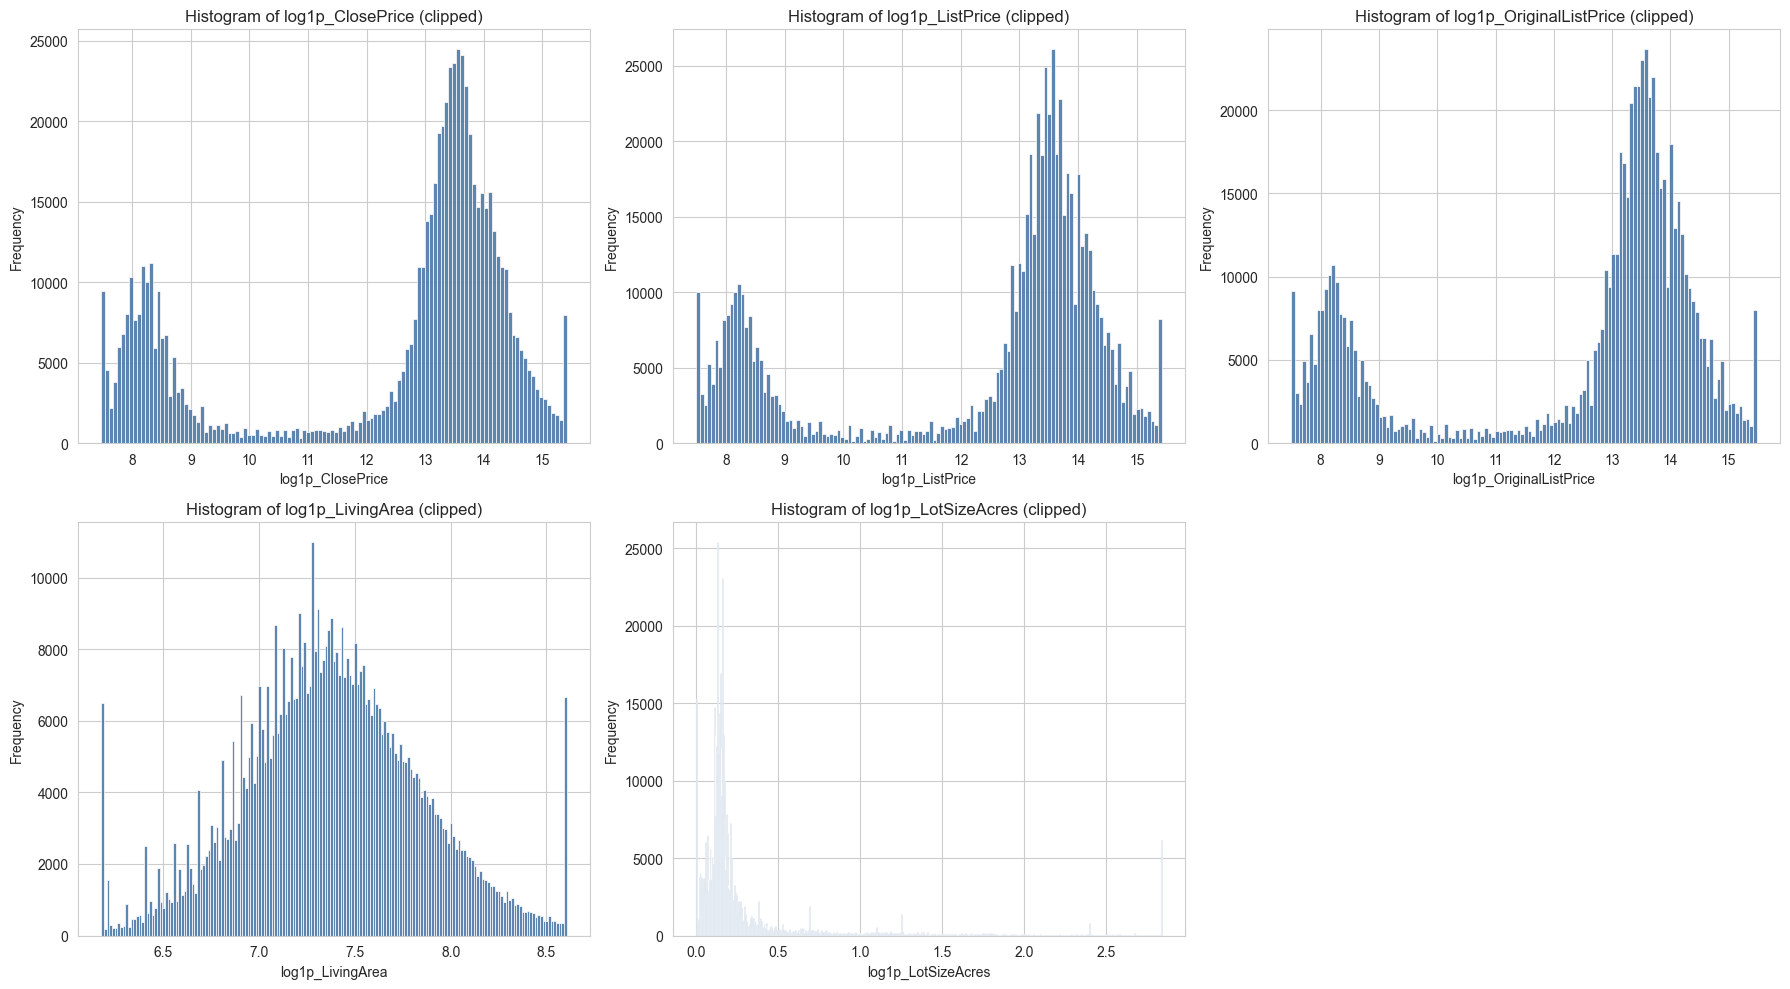

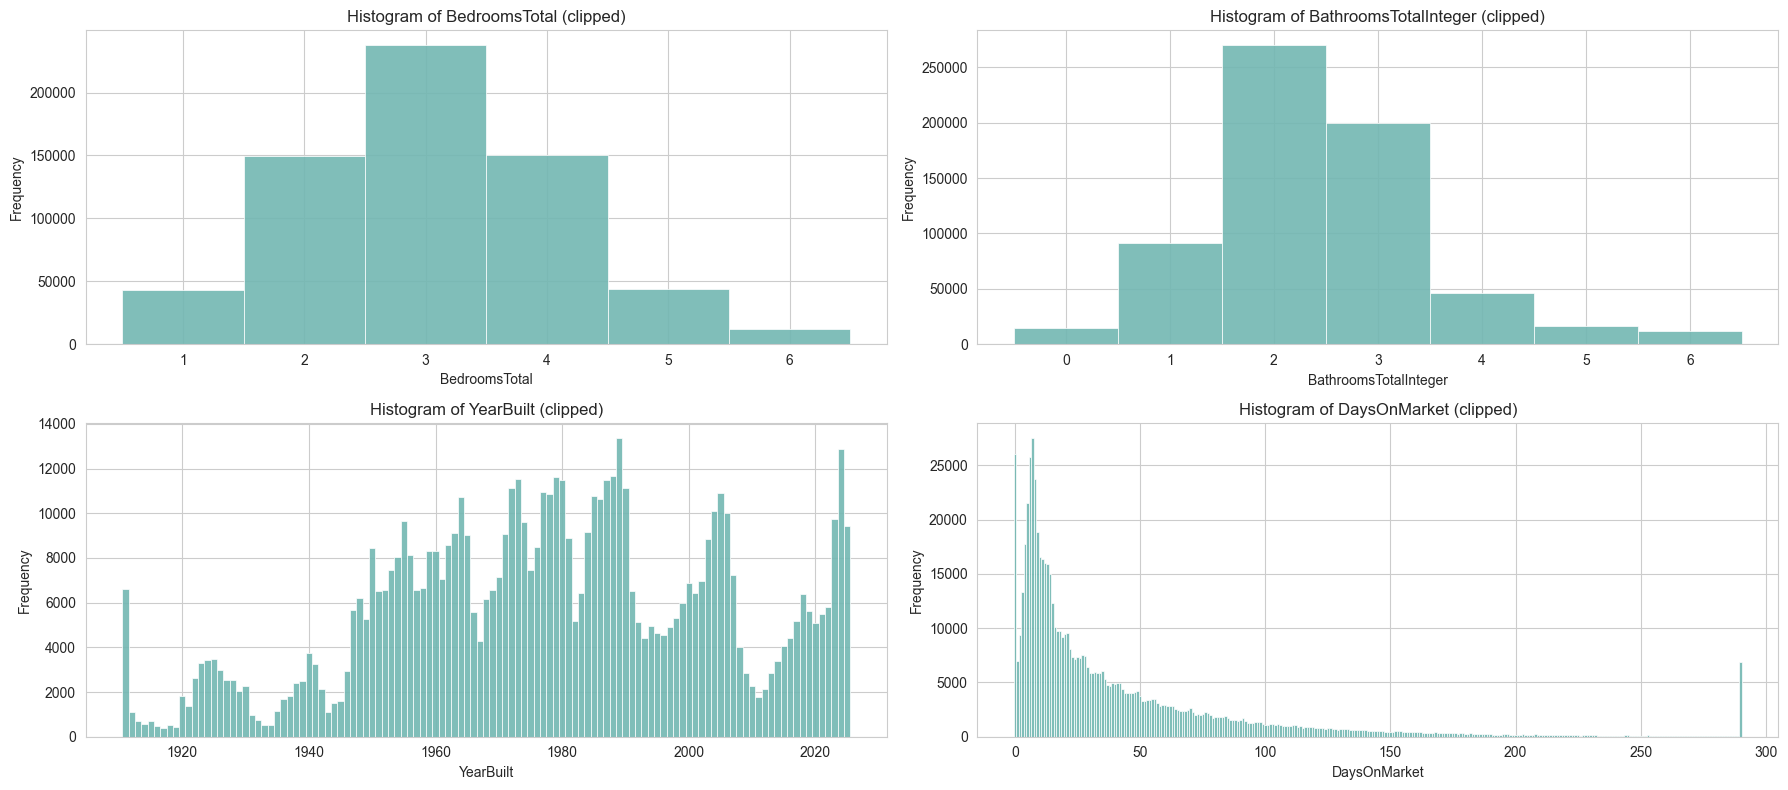

In [ ]:
# same visualizations but for sold data
plot_df = sold_df_raw.copy()
plot_df["DaysOnMarket"] = pd.to_numeric(plot_df["DaysOnMarket"], errors="coerce").clip(
    lower=0
)

# Use log1p on heavy-tailed continuous features for better shape visibility.
log_cols = []
for column in CONTINUOUS_COLS:
    log_col = f"log1p_{column}"
    values = pd.to_numeric(plot_df[column], errors="coerce").clip(lower=0)
    plot_df[log_col] = np.log1p(values)
    log_cols.append(log_col)

get_histogram(
    plot_df,
    col=log_cols,
    bins="auto",
    clip_lower=plot_df[log_cols].quantile(0.01),
    clip_upper=plot_df[log_cols].quantile(0.99),
    ncols=3,
    figsize=(18, 10),
    edgecolor="white",
    linewidth=0.5,
    color="#4C78A8",
    alpha=0.9,
)

get_histogram(
    plot_df,
    col=DISCRETE_COLS,
    bins="auto",
    clip_lower=plot_df[DISCRETE_COLS].quantile(0.01),
    clip_upper=plot_df[DISCRETE_COLS].quantile(
        0.99
    ),  # clipping needed because the scale goes insane otherwise aka lots of outliers > : (
    ncols=2,
    figsize=(18, 8),
    edgecolor="white",
    linewidth=0.5,
    color="#72B7B2",
    alpha=0.9,
    discrete=True,
)

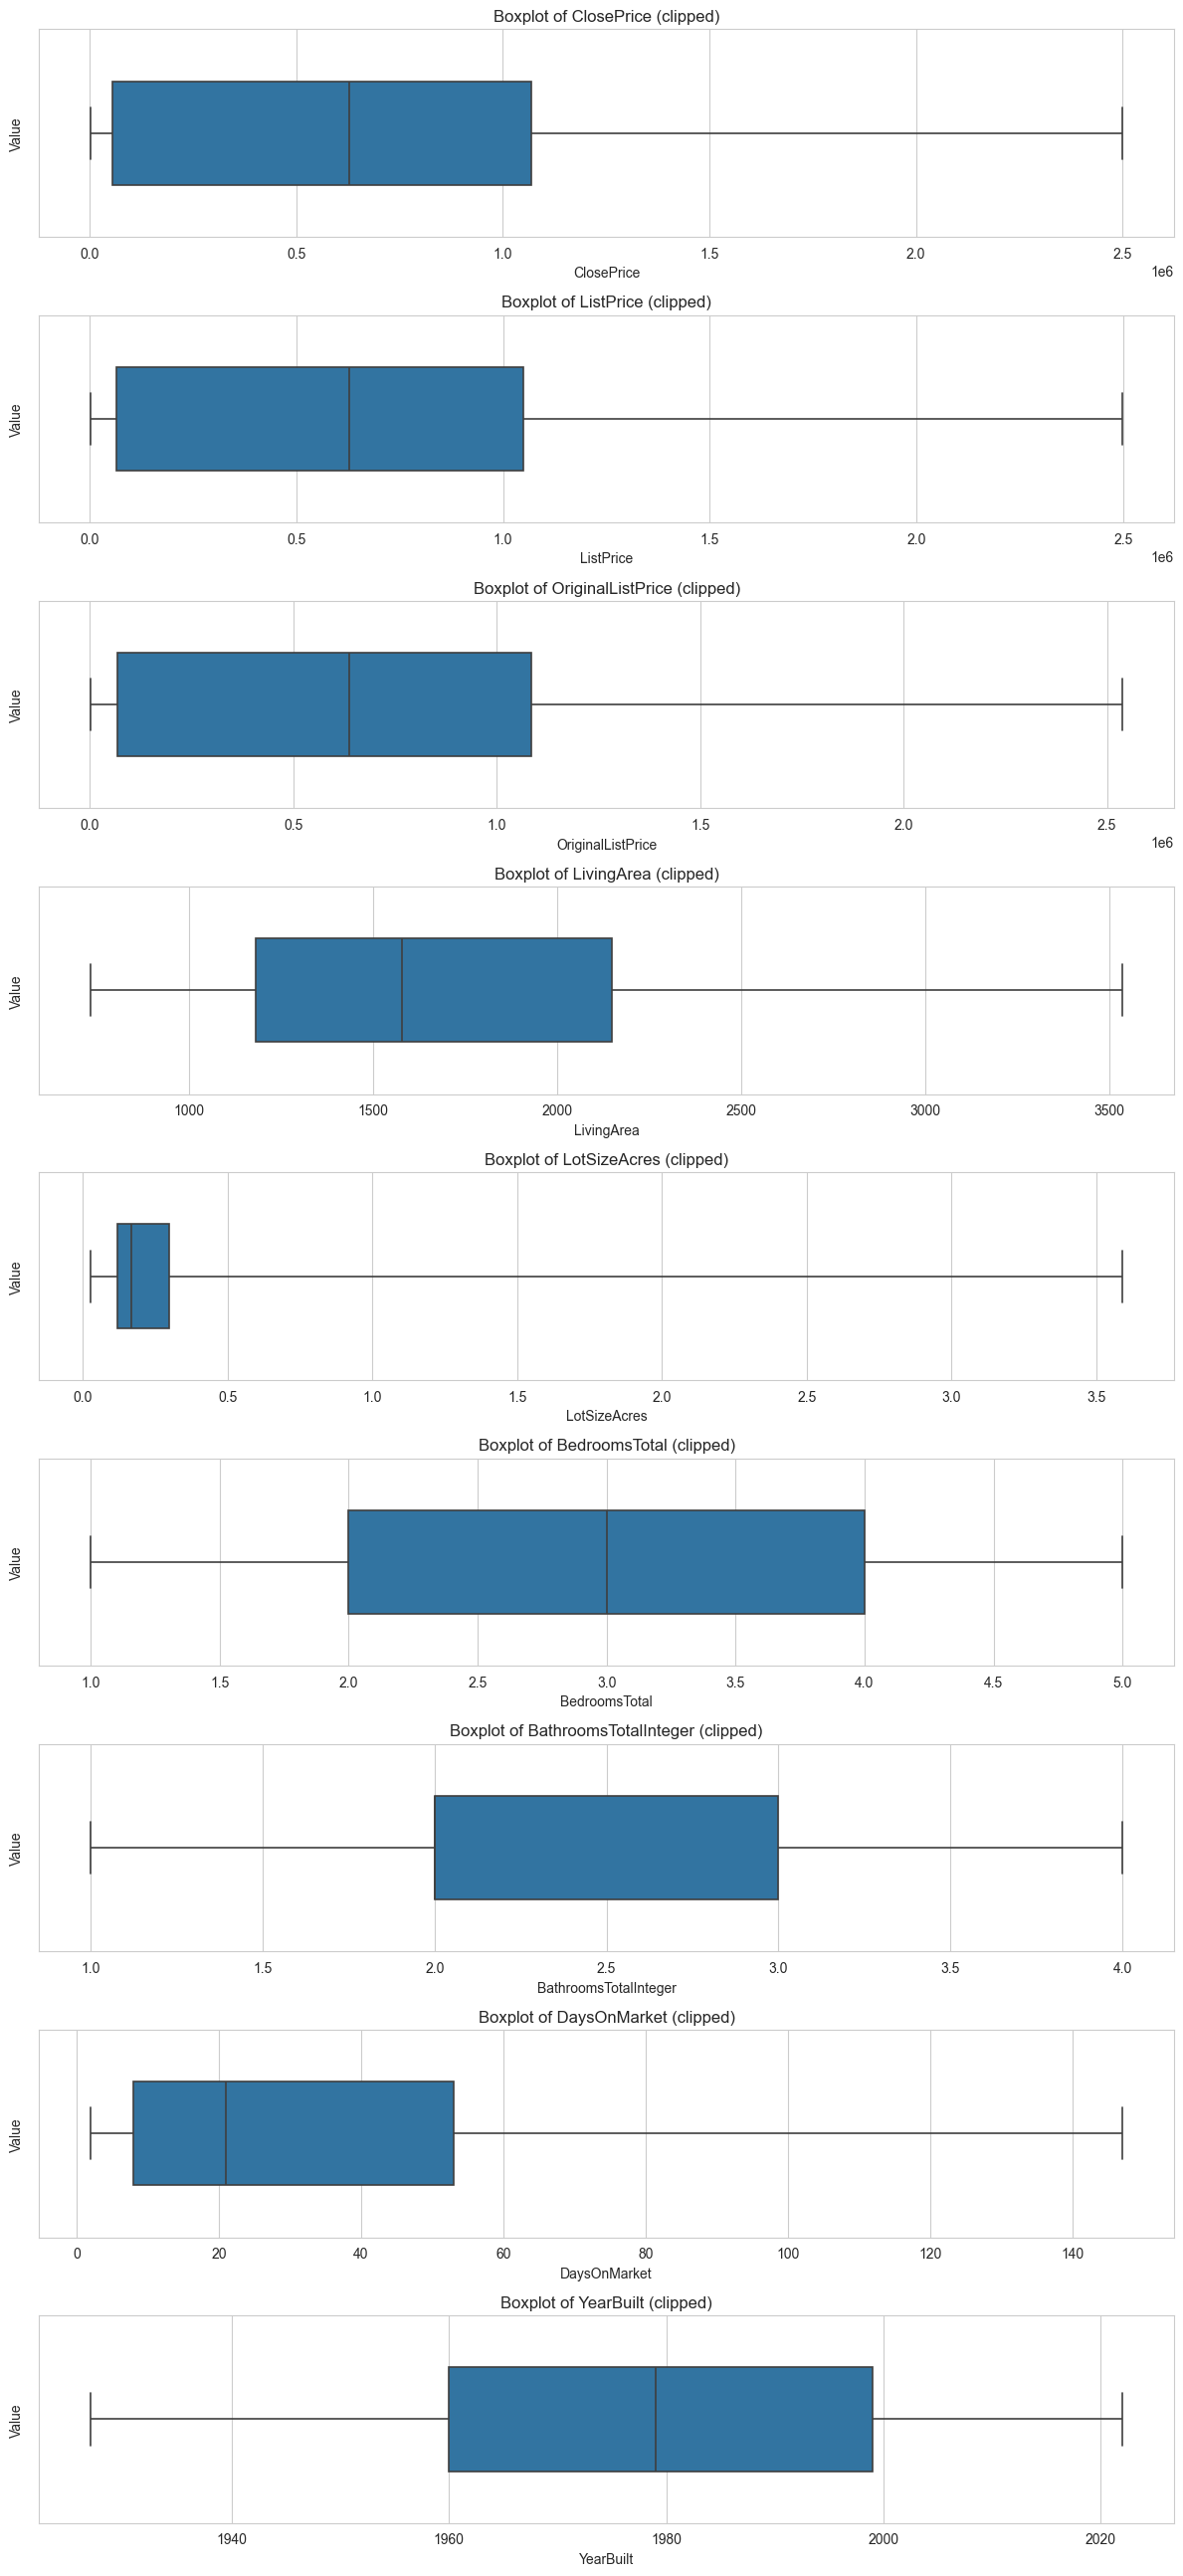

In [ ]:
get_boxplot(
    sold_df_raw,
    col=NUMERIC_FIELDS_TO_ANALYZE,
    clip_lower=sold_df_raw[NUMERIC_FIELDS_TO_ANALYZE].quantile(0.01),
    clip_upper=sold_df_raw[NUMERIC_FIELDS_TO_ANALYZE].quantile(0.99),
    ncols=1,
    figsize=(12, 26),
    showfliers=False,
    whis=(5, 95),
    linewidth=1.2,
    width=0.5,
)

In [83]:
# distribution analysis
print("Sold DataFrame Distribution Analysis:")
display(sold_df_raw[DISTR_COLS].describe())

# percentile breakdowns
print("Sold DataFrame Percentile Breakdown:")
display(sold_df_raw[NUMERIC_FIELDS_TO_ANALYZE].describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]).T)


Sold DataFrame Distribution Analysis:


,ClosePrice,LivingArea,DaysOnMarket
count,6.815920e+05,6.332170e+05,681599.000000
mean,8.747685e+05,3.272836e+03,43.061059
std,5.277749e+06,1.142632e+06,70.086772
min,0.000000e+00,0.000000e+00,-288.000000
25%,5.500000e+04,1.183000e+03,8.000000
50%,6.290000e+05,1.579000e+03,21.000000
75%,1.070000e+06,2.150000e+03,53.000000
max,9.895000e+08,9.090909e+08,12430.000000


Sold DataFrame Percentile Breakdown:


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
ClosePrice,681592.0,874768.467905,5.277749e+06,0.0,1750.0,2695.0000,3495.0000,55000.0000,629000.0000,1.070000e+06,1.785000e+06,2500000.00,4.979090e+06,9.895000e+08
ListPrice,680567.0,838885.930237,1.271547e+06,0.0,1795.0,2700.0000,3500.0000,65000.0000,629000.0000,1.050000e+06,1.777000e+06,2498000.00,4.998000e+06,1.375000e+08
OriginalListPrice,679615.0,901839.732604,5.562279e+06,0.0,1800.0,2750.0000,3500.0000,69000.0000,639000.0000,1.085000e+06,1.799000e+06,2538000.00,5.295000e+06,1.390000e+09
LivingArea,633217.0,3272.836298,1.142632e+06,0.0,480.0,734.0000,895.0000,1183.0000,1579.0000,2.150000e+03,2.921000e+03,3536.00,5.464000e+03,9.090909e+08
LotSizeAcres,616700.0,681.300926,4.717737e+05,0.0,0.0,0.0275,0.0574,0.1194,0.1676,2.984000e-01,1.272910e+00,3.59,1.612010e+01,3.702600e+08
BedroomsTotal,635886.0,3.078520,1.395030e+00,0.0,1.0,1.0000,2.0000,2.0000,3.0000,4.000000e+00,4.000000e+00,5.00,6.000000e+00,1.800000e+02
BathroomsTotalInteger,649786.0,2.444382,1.407900e+00,0.0,0.0,1.0000,1.0000,2.0000,2.0000,3.000000e+00,4.000000e+00,4.00,6.000000e+00,1.750000e+02
DaysOnMarket,681599.0,43.061059,7.008677e+01,-288.0,0.0,2.0000,4.0000,8.0000,21.0000,5.300000e+01,1.030000e+02,147.00,2.900000e+02,1.243000e+04
YearBuilt,652606.0,1978.140224,2.706913e+01,1776.0,1911.0,1927.0000,1945.0000,1960.0000,1979.0000,1.999000e+03,2.017000e+03,2022.00,2.025000e+03,2.026000e+03


### Sold Outlier Detection

In [84]:
print("Sold DataFrame Outlier Analysis:")
numeric_outliers = get_iqr_outliers(sold_df_raw, NUMERIC_FIELDS_TO_ANALYZE, threshold=3.0) # 3.0 for EXTREME outliers

Sold DataFrame Outlier Analysis:
Outlier Counts (Threshold: 3.0 * IQR)
----------------------------------------
ClosePrice: 10808 outliers (1.59% of total records)
ListPrice: 11140 outliers (1.63% of total records)
OriginalListPrice: 11830 outliers (1.74% of total records)
LivingArea: 8408 outliers (1.23% of total records)
LotSizeAcres: 80702 outliers (11.84% of total records)
BedroomsTotal: 970 outliers (0.14% of total records)
BathroomsTotalInteger: 5262 outliers (0.77% of total records)
DaysOnMarket: 19103 outliers (2.80% of total records)
YearBuilt: 29 outliers (0.00% of total records)
